# Baseline demand model for Yellow Taxi

## Цель
Построить baseline-модель для прогнозирования количества поездок Yellow Taxi
по геозонам и часам.

## Важное упрощение
Чтобы Colab не падал по памяти, в этой версии ноутбука используем **только март 2024**.

## Постановка задачи
**Target:** количество поездок, начавшихся в зоне `PULocationID` за 1 час.

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/MLOps"

trip_file = os.path.join(BASE_PATH, "yellow_tripdata_2024-03.parquet")
weather_file = os.path.join(BASE_PATH, "open-meteo-40.74N74.04W51m.csv")
zones_file = os.path.join(BASE_PATH, "NYC_Taxi_Zones_20260326.geojson")

for path in [trip_file, weather_file, zones_file]:
    print(path, "->", os.path.exists(path))

/content/drive/MyDrive/Colab Notebooks/MLOps/yellow_tripdata_2024-03.parquet -> True
/content/drive/MyDrive/Colab Notebooks/MLOps/open-meteo-40.74N74.04W51m.csv -> True
/content/drive/MyDrive/Colab Notebooks/MLOps/NYC_Taxi_Zones_20260326.geojson -> True


## 1. Читаем поездки
Берём только нужные колонки, чтобы не раздувать память пока тестовое и только один месяц из планируемых четырех.

In [ ]:
trip_cols = ["tpep_pickup_datetime", "PULocationID"]

trips = pd.read_parquet(trip_file, columns=trip_cols)

print(trips.shape)
trips.head()

(3582628, 2)


,tpep_pickup_datetime,PULocationID
0,2024-03-01 00:18:51,142
1,2024-03-01 00:26:00,238
2,2024-03-01 00:09:22,263
3,2024-03-01 00:33:45,164
4,2024-03-01 00:05:43,263


In [ ]:
trips.info()
trips.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3582628 entries, 0 to 3582627
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   PULocationID          int32         
dtypes: datetime64[us](1), int32(1)
memory usage: 41.0 MB


,0
tpep_pickup_datetime,0
PULocationID,0


## 2. Минимальная очистка и фильтрация на март 2024

Именно этот блок нужен, чтобы убрать аномальные записи с неправильными датами
(из-за них у вас раньше появлялся 2002 год и Colab падал по памяти).

In [ ]:
trips = trips.dropna(subset=["tpep_pickup_datetime", "PULocationID"]).copy()

trips["tpep_pickup_datetime"] = pd.to_datetime(trips["tpep_pickup_datetime"])
trips["PULocationID"] = trips["PULocationID"].astype(int)

# Оставляем только март 2024
trips = trips[
    (trips["tpep_pickup_datetime"] >= "2024-03-01") &
    (trips["tpep_pickup_datetime"] < "2024-04-01")
].copy()

print("Trips min:", trips["tpep_pickup_datetime"].min())
print("Trips max:", trips["tpep_pickup_datetime"].max())
print("Trips shape:", trips.shape)

trips.head()

Trips min: 2024-03-01 00:00:00
Trips max: 2024-03-31 23:59:59
Trips shape: (3582605, 2)


,tpep_pickup_datetime,PULocationID
0,2024-03-01 00:18:51,142
1,2024-03-01 00:26:00,238
2,2024-03-01 00:09:22,263
3,2024-03-01 00:33:45,164
4,2024-03-01 00:05:43,263


## 3. Читаем и готовим погоду

In [ ]:
weather = pd.read_csv(weather_file, skiprows=3)

weather = weather.rename(columns={
    "time": "pickup_hour",
    "temperature_2m (°C)": "temperature_2m",
    "relative_humidity_2m (%)": "relative_humidity_2m",
    "precipitation (mm)": "precipitation",
    "weather_code (wmo code)": "weather_code",
    "wind_speed_10m (km/h)": "wind_speed_10m"
})

weather["pickup_hour"] = pd.to_datetime(weather["pickup_hour"])

weather = weather[[
    "pickup_hour",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "weather_code",
    "wind_speed_10m"
]].copy()

# Для аккуратности тоже оставляем только март 2024
weather = weather[
    (weather["pickup_hour"] >= "2024-03-01") &
    (weather["pickup_hour"] < "2024-04-01")
].copy()

print("Weather min:", weather["pickup_hour"].min())
print("Weather max:", weather["pickup_hour"].max())
print("Weather shape:", weather.shape)

weather.head()

Weather min: 2024-03-01 00:00:00
Weather max: 2024-03-31 23:00:00
Weather shape: (744, 6)


,pickup_hour,temperature_2m,relative_humidity_2m,precipitation,weather_code,wind_speed_10m
0,2024-03-01 00:00:00,-0.1,45,0.0,0,7.6
1,2024-03-01 01:00:00,0.1,46,0.0,0,10.0
2,2024-03-01 02:00:00,-1.1,52,0.0,0,7.6
3,2024-03-01 03:00:00,-1.8,55,0.0,0,7.6
4,2024-03-01 04:00:00,-2.2,56,0.0,0,7.9


## 4. Создаём час поездки

In [ ]:
trips["pickup_hour"] = trips["tpep_pickup_datetime"].dt.floor("h")

trips[["tpep_pickup_datetime", "pickup_hour", "PULocationID"]].head()

,tpep_pickup_datetime,pickup_hour,PULocationID
0,2024-03-01 00:18:51,2024-03-01,142
1,2024-03-01 00:26:00,2024-03-01,238
2,2024-03-01 00:09:22,2024-03-01,263
3,2024-03-01 00:33:45,2024-03-01,164
4,2024-03-01 00:05:43,2024-03-01,263


## 5. Агрегируем поездки в формат `zone × hour`

In [ ]:
agg_trips = (
    trips.groupby(["pickup_hour", "PULocationID"])
    .size()
    .reset_index(name="trip_count")
)

print("Agg min:", agg_trips["pickup_hour"].min())
print("Agg max:", agg_trips["pickup_hour"].max())
print("Agg shape:", agg_trips.shape)

agg_trips.head()

Agg min: 2024-03-01 00:00:00
Agg max: 2024-03-31 23:00:00
Agg shape: (89011, 3)


,pickup_hour,PULocationID,trip_count
0,2024-03-01,4,15
1,2024-03-01,7,1
2,2024-03-01,13,3
3,2024-03-01,22,1
4,2024-03-01,24,4


## 6. Освобождаем память
Сырые поездки больше не нужны.

In [ ]:
del trips
gc.collect()

109

## 7. Строим полную сетку часов и зон
Это нужно, чтобы появились нулевые значения спроса, а не только часы, где поездки были.

In [ ]:
all_hours = pd.date_range(
    start=agg_trips["pickup_hour"].min(),
    end=agg_trips["pickup_hour"].max(),
    freq="h"
)

all_zones = sorted(agg_trips["PULocationID"].unique())

full_grid = pd.MultiIndex.from_product(
    [all_hours, all_zones],
    names=["pickup_hour", "PULocationID"]
).to_frame(index=False)

print("Full grid shape:", full_grid.shape)
full_grid.head()

Full grid shape: (192696, 2)


,pickup_hour,PULocationID
0,2024-03-01,1
1,2024-03-01,2
2,2024-03-01,3
3,2024-03-01,4
4,2024-03-01,5


## 8. Формируем итоговый датасет и присоединяем погоду

In [ ]:
dataset = full_grid.merge(
    agg_trips,
    on=["pickup_hour", "PULocationID"],
    how="left"
)

dataset["trip_count"] = dataset["trip_count"].fillna(0).astype(int)

# Больше не нужны
del full_grid
del agg_trips
gc.collect()

print("Dataset before weather merge:", dataset.shape)
dataset.head()

Dataset before weather merge: (192696, 3)


,pickup_hour,PULocationID,trip_count
0,2024-03-01,1,0
1,2024-03-01,2,0
2,2024-03-01,3,0
3,2024-03-01,4,15
4,2024-03-01,5,0


In [ ]:
dataset = dataset.merge(
    weather,
    on="pickup_hour",
    how="left"
)

del weather
gc.collect()

print("Dataset after weather merge:", dataset.shape)
dataset.head()

Dataset after weather merge: (192696, 8)


,pickup_hour,PULocationID,trip_count,temperature_2m,relative_humidity_2m,precipitation,weather_code,wind_speed_10m
0,2024-03-01,1,0,-0.1,45,0.0,0,7.6
1,2024-03-01,2,0,-0.1,45,0.0,0,7.6
2,2024-03-01,3,0,-0.1,45,0.0,0,7.6
3,2024-03-01,4,15,-0.1,45,0.0,0,7.6
4,2024-03-01,5,0,-0.1,45,0.0,0,7.6


In [ ]:
dataset.isna().sum()

,0
pickup_hour,0
PULocationID,0
trip_count,0
temperature_2m,0
relative_humidity_2m,0
precipitation,0
weather_code,0
wind_speed_10m,0


## 9. Создаём временные признаки

In [ ]:
dataset["hour"] = dataset["pickup_hour"].dt.hour
dataset["day_of_week"] = dataset["pickup_hour"].dt.dayofweek
dataset["month"] = dataset["pickup_hour"].dt.month
dataset["day"] = dataset["pickup_hour"].dt.day
dataset["is_weekend"] = dataset["day_of_week"].isin([5, 6]).astype(int)

dataset.head()

,pickup_hour,PULocationID,trip_count,temperature_2m,relative_humidity_2m,precipitation,weather_code,wind_speed_10m,hour,day_of_week,month,day,is_weekend
0,2024-03-01,1,0,-0.1,45,0.0,0,7.6,0,4,3,1,0
1,2024-03-01,2,0,-0.1,45,0.0,0,7.6,0,4,3,1,0
2,2024-03-01,3,0,-0.1,45,0.0,0,7.6,0,4,3,1,0
3,2024-03-01,4,15,-0.1,45,0.0,0,7.6,0,4,3,1,0
4,2024-03-01,5,0,-0.1,45,0.0,0,7.6,0,4,3,1,0


## 10. Готовим признаки и target

In [ ]:
feature_cols = [
    "PULocationID",
    "hour",
    "day_of_week",
    "month",
    "day",
    "is_weekend",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "weather_code",
    "wind_speed_10m"
]

target_col = "trip_count"

model_df = dataset[feature_cols + [target_col, "pickup_hour"]].copy()

print(model_df.shape)
model_df.head()

(192696, 13)


,PULocationID,hour,day_of_week,month,day,is_weekend,temperature_2m,relative_humidity_2m,precipitation,weather_code,wind_speed_10m,trip_count,pickup_hour
0,1,0,4,3,1,0,-0.1,45,0.0,0,7.6,0,2024-03-01
1,2,0,4,3,1,0,-0.1,45,0.0,0,7.6,0,2024-03-01
2,3,0,4,3,1,0,-0.1,45,0.0,0,7.6,0,2024-03-01
3,4,0,4,3,1,0,-0.1,45,0.0,0,7.6,15,2024-03-01
4,5,0,4,3,1,0,-0.1,45,0.0,0,7.6,0,2024-03-01


## 11. Делим на train/test по времени

Так как мы сейчас используем только март, делим внутри марта:
- train: до 25 марта
- test: с 25 марта и позже

In [ ]:
split_date = pd.Timestamp("2024-03-25 00:00:00")

train_df = model_df[model_df["pickup_hour"] < split_date].copy()
test_df = model_df[model_df["pickup_hour"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (149184, 13)
Test shape: (43512, 13)


In [ ]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

## 12. Настраиваем препроцессинг

In [ ]:
categorical_features = ["PULocationID", "weather_code", "day_of_week", "month", "hour"]
numeric_features = ["day", "is_weekend", "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features),
    ]
)

## 13. Обучаем baseline-модель

In [ ]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", PoissonRegressor(alpha=1.0, max_iter=300))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PULocationID',
                                                   'weather_code',
                                                   'day_of_week', 'month',
                                                   'hour']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['day', 'is_weekend',
                                                   'temperature_2m',
                                                   'relative_humidity_2m',
                                                   'precipitation',
                                                   'wind_speed_10m'])])),
                ('model', PoissonRegressor(max_iter=300))])

In [ ]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

MAE: 26.2755
RMSE: 50.4687


In [ ]:
comparison = pd.DataFrame({
    "actual": y_test.values[:20],
    "predicted": y_pred[:20]
})

comparison

,actual,predicted
0,0,11.840408
1,0,11.819295
2,0,11.826725
3,7,12.252933
4,0,11.818850
5,0,11.820558
6,3,11.960691
7,0,11.819444
8,0,11.821970
9,0,11.895063


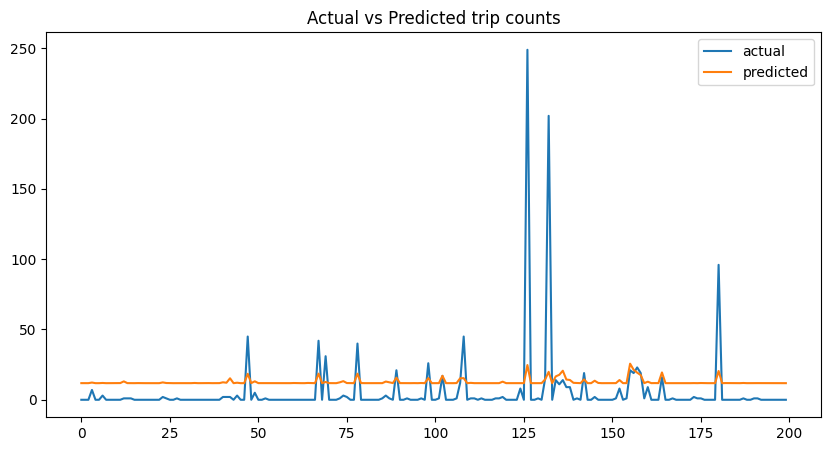

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:200], label="actual")
plt.plot(y_pred[:200], label="predicted")
plt.legend()
plt.title("Actual vs Predicted trip counts")
plt.show()

## 14. Сохраняем артефакты
Артефакты = сохранённая модель и файл с метриками.

In [ ]:
artifacts_dir = os.path.join(BASE_PATH, "artifacts")
os.makedirs(artifacts_dir, exist_ok=True)

model_path = os.path.join(artifacts_dir, "baseline_poisson_model_march.joblib")
metrics_path = os.path.join(artifacts_dir, "baseline_metrics_march.csv")

joblib.dump(baseline_model, model_path)

metrics = pd.DataFrame([{
    "model_name": "PoissonRegressor_baseline_march",
    "mae": mae,
    "rmse": rmse
}])
metrics.to_csv(metrics_path, index=False)

print("Model saved to:", model_path)
print("Metrics saved to:", metrics_path)
metrics

Model saved to: /content/drive/MyDrive/Colab Notebooks/MLOps/artifacts/baseline_poisson_model_march.joblib
Metrics saved to: /content/drive/MyDrive/Colab Notebooks/MLOps/artifacts/baseline_metrics_march.csv


,model_name,mae,rmse
0,PoissonRegressor_baseline_march,26.275525,50.468691


## Итог

В этом ноутбуке:
- прочитали поездки и погоду,
- отфильтровали данные на март 2024,
- собрали таблицу `zone × hour`,
- сформировали target `trip_count`,
- обучили baseline-модель `PoissonRegressor`,
- посчитали MAE и RMSE,
- сохранили модель и метрики.